## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Data Loading

In [2]:
df = pd.read_csv('credit_card_data.csv')

print(df.shape)

(8950, 18)


Shape : 8,950 rows × 18 columns

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
print(df.describe().round(2).to_string())

        BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT   TENURE
count   8950.00            8950.00    8950.00           8950.00                 8950.00       8950.00              8950.00                     8950.00                           8950.00                 8950.00           8950.00        8950.00       8949.00   8950.00           8637.00           8950.00  8950.00
mean    1564.47               0.88    1003.20            592.44                  411.07        978.87                 0.49                        0.20                              0.36                    0.14              3.25          14.71       4494.45   1733.14            864.21              0.15    11.52
std     2081.53               0.24    2136.63           1659.89    

In [6]:
df.nunique()

CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

## Missing Value Analysis

In [7]:
missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_%' : (df.isnull().mean()*100).round(2)
}).sort_values('missing_%', ascending=False)
print("Comumns With Missing Values: ")
print(missing_df.to_string())

Comumns With Missing Values: 
                                  missing_count  missing_%
MINIMUM_PAYMENTS                            313       3.50
CREDIT_LIMIT                                  1       0.01
BALANCE                                       0       0.00
CUST_ID                                       0       0.00
BALANCE_FREQUENCY                             0       0.00
PURCHASES                                     0       0.00
CASH_ADVANCE                                  0       0.00
PURCHASES_FREQUENCY                           0       0.00
ONEOFF_PURCHASES                              0       0.00
INSTALLMENTS_PURCHASES                        0       0.00
PURCHASES_INSTALLMENTS_FREQUENCY              0       0.00
ONEOFF_PURCHASES_FREQUENCY                    0       0.00
CASH_ADVANCE_TRX                              0       0.00
CASH_ADVANCE_FREQUENCY                        0       0.00
PURCHASES_TRX                                 0       0.00
PAYMENTS                  

### Insights:
> MINIMUM_PAYMENTS -- 313 Missing Value (data might be skewed, use median imputing)

> CREDIT_LIMIT -- 1 Missing Value (data might be skewed, use median imputing)

# Preprocessing

In [8]:
df_clean = df.copy() # Made a copy

In [9]:
cols_to_drop = ['CUST_ID']
df_clean = df_clean.drop(columns=cols_to_drop)
print(f'{cols_to_drop} are droped ✅')

['CUST_ID'] are droped ✅


In [10]:
print(df_clean.columns)

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')


In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

### We have 17 Numerical feature 

## Handle Missing Values

In [12]:
# 1. Fill MINIMUM_PAYMENTS with Median
df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median(), inplace=True)
print(f"✅ Filled 'MINIMUM_PAYMENTS' missing value with median: {df_clean['MINIMUM_PAYMENTS'].median()}")
# 2. Fill CREDIT_LIMIT with Median
df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median(), inplace=True)
print(f"✅ Filled 'CREDIT_LIMIT' missing value with median: {df_clean['CREDIT_LIMIT'].median()}")


✅ Filled 'MINIMUM_PAYMENTS' missing value with median: 312.343947
✅ Filled 'CREDIT_LIMIT' missing value with median: 3000.0


C:\Users\david\AppData\Local\Temp\ipykernel_23876\400361200.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median(), inplace=True)
C:\Users\david\AppData\Local\Temp\ipykernel_23876\400361200.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

## Verifying Missing Values

In [13]:
missing_df = pd.DataFrame({
    'missing_count': df_clean.isnull().sum()
})
print("Columns with Missing Values:")
print(missing_df.to_string())

Columns with Missing Values:
                                  missing_count
BALANCE                                       0
BALANCE_FREQUENCY                             0
PURCHASES                                     0
ONEOFF_PURCHASES                              0
INSTALLMENTS_PURCHASES                        0
CASH_ADVANCE                                  0
PURCHASES_FREQUENCY                           0
ONEOFF_PURCHASES_FREQUENCY                    0
PURCHASES_INSTALLMENTS_FREQUENCY              0
CASH_ADVANCE_FREQUENCY                        0
CASH_ADVANCE_TRX                              0
PURCHASES_TRX                                 0
CREDIT_LIMIT                                  0
PAYMENTS                                      0
MINIMUM_PAYMENTS                              0
PRC_FULL_PAYMENT                              0
TENURE                                        0


## Features Engineering

In [14]:
df_clean['SPEND_INTENSITY']    = df_clean['PURCHASES'] / (df_clean['CREDIT_LIMIT'] + 1)
df_clean['PAYMENT_DISCIPLINE'] = df_clean['PAYMENTS'] / (df_clean['MINIMUM_PAYMENTS'] + 1)
df_clean['REVOLVING_BEHAVIOR'] = df_clean['BALANCE'] / (df_clean['CREDIT_LIMIT'] + 1)
df_clean['CASH_DEPENDENCY']    = df_clean['CASH_ADVANCE'] / (df_clean['PURCHASES'] + 1)

> 'SPEND_INTENSITY'→ Out of the total credit limit given to them, how much did they actually spend

> 'PAYMENT_DISCIPLINE'→ How much MORE than the minimum are they paying

> 'REVOLVING_BEHAVIOR'→ What percentage of their credit limit is left as unpaid balance, This is basically the credit utilization ratio

> 'CASH_DEPENDENCY'→ For every rupee they spend on purchases, how much do they withdraw as cash.

## Droping Unimportant Features

In [15]:
cols_to_drop = ['MINIMUM_PAYMENTS', 'PAYMENTS', 'CASH_ADVANCE',  'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'BALANCE', 'CREDIT_LIMIT', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']
df_clean = df_clean.drop(columns=cols_to_drop)
print(f'{cols_to_drop} are droped ✅')

['MINIMUM_PAYMENTS', 'PAYMENTS', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'BALANCE', 'CREDIT_LIMIT', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY'] are droped ✅


## Checking For Skewness

In [16]:
print(f'SKEWNESS CHECK BEFORE---------------------------')

print(df_clean.skew().sort_values(ascending=False))

SKEWNESS CHECK BEFORE---------------------------
PAYMENT_DISCIPLINE            36.902249
ONEOFF_PURCHASES              10.045083
PURCHASES                      8.144269
INSTALLMENTS_PURCHASES         7.299120
REVOLVING_BEHAVIOR             7.083895
CASH_DEPENDENCY                5.931663
SPEND_INTENSITY                5.270067
PRC_FULL_PAYMENT               1.942820
ONEOFF_PURCHASES_FREQUENCY     1.535613
BALANCE_FREQUENCY             -2.023266
TENURE                        -2.943017
dtype: float64


Skewness Thresholds (Industry Rule)

Skewness ValueAction

💠 < 0.5 Leave it alone

💠 0.5 – 1.0 Optional transform

💠 > 1.0 Apply log transform

💠 > 3.0 Cap first, then log

In [17]:
# These need CAPPING + LOG (skew > 3)
# PAYMENT_DISCIPLINE            36.902249
# ONEOFF_PURCHASES              10.045083
# PURCHASES                      8.144269
# INSTALLMENTS_PURCHASES         7.299120
# REVOLVING_BEHAVIOR             7.083895
# CASH_DEPENDENCY                5.931663
# SPEND_INTENSITY                5.270067


# These need only LOG (1 < skew < 3)
# PRC_FULL_PAYMENT               1.942820
# ONEOFF_PURCHASES_FREQUENCY     1.535613



# NEGATIVE skew — different treatment
# BALANCE_FREQUENCY             -2.023266
# TENURE                        -2.943017

In [18]:
print(df_clean.columns)

Index(['BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY',
       'PRC_FULL_PAYMENT', 'TENURE', 'SPEND_INTENSITY', 'PAYMENT_DISCIPLINE',
       'REVOLVING_BEHAVIOR', 'CASH_DEPENDENCY'],
      dtype='object')


In [19]:
cols_raw = ['BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY',
       'PRC_FULL_PAYMENT', 'TENURE', 'SPEND_INTENSITY', 'PAYMENT_DISCIPLINE',
       'REVOLVING_BEHAVIOR', 'CASH_DEPENDENCY']

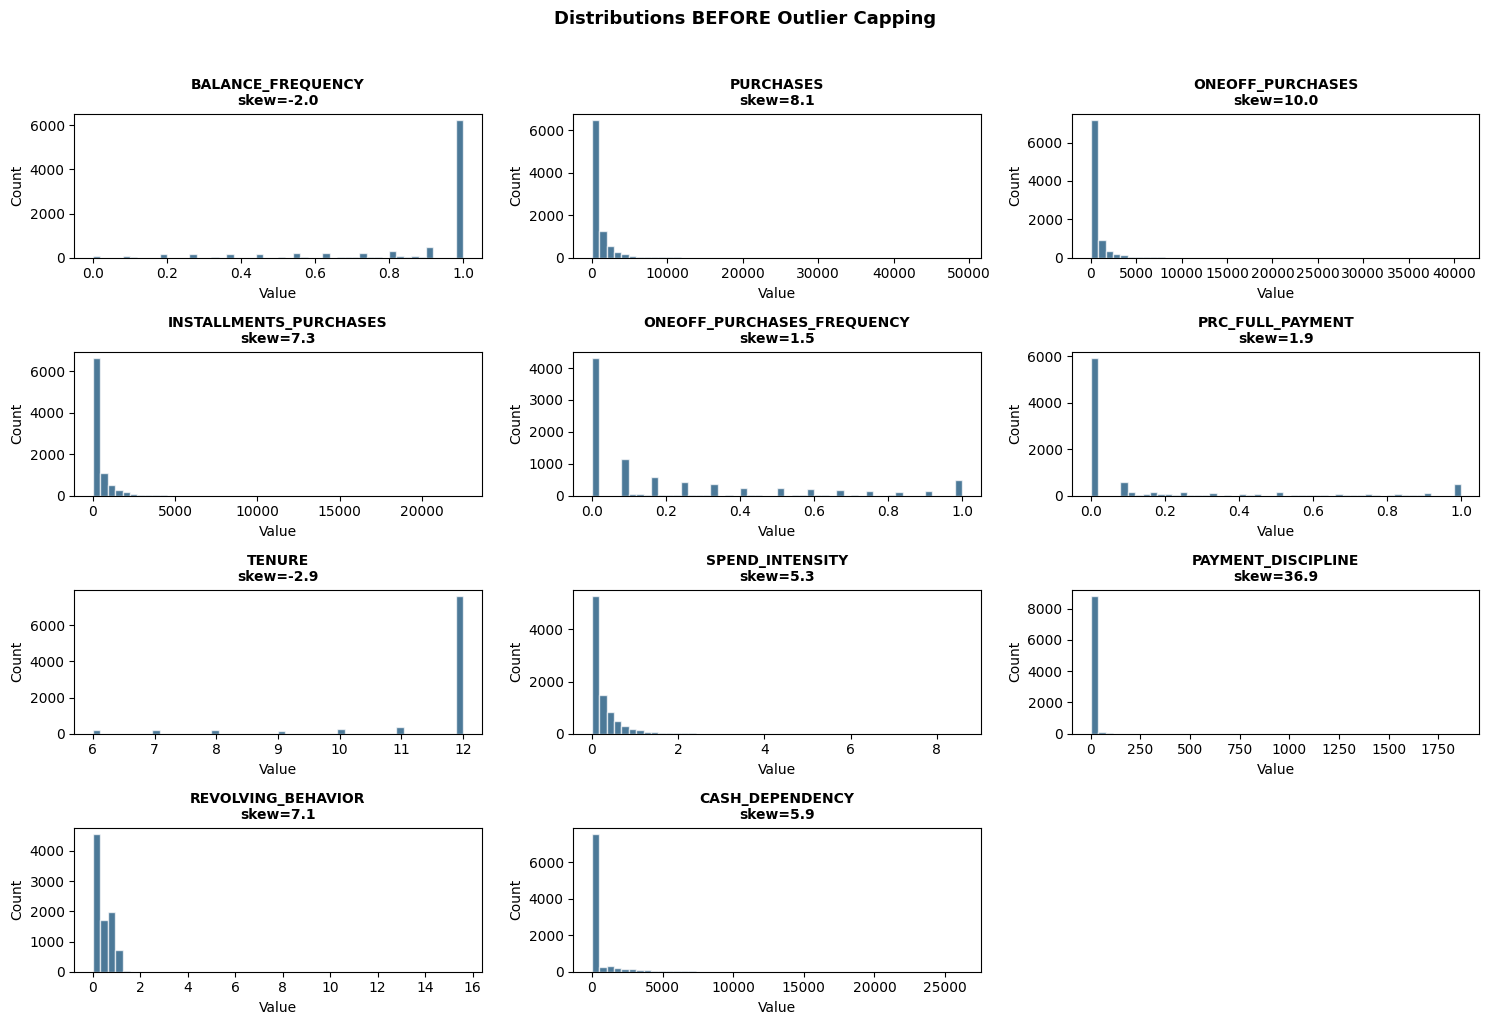

In [20]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10)) 
axes = axes.flatten()

for i, col in enumerate(cols_raw):
    # This will now work up to index 8 (the 9th item)
    axes[i].hist(df_clean[col].dropna(), bins=50, color="#00416c", alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col}\nskew={df_clean[col].skew():.1f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Distributions BEFORE Outlier Capping', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:

high_skew_cols = ['PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
       'SPEND_INTENSITY', 'PAYMENT_DISCIPLINE', 'REVOLVING_BEHAVIOR',
       'CASH_DEPENDENCY']

for col in high_skew_cols:
    orignal_max = df_clean[col].max()
    df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])  # cap bottom & top 1%
    cap_max = df_clean[col].max()
    print(f"{col:<35} Cap = {cap_max:>6.1f}  |  Orignal Max = {orignal_max}")   

PURCHASES                           Cap = 9007.7  |  Orignal Max = 49039.57
ONEOFF_PURCHASES                    Cap = 6701.1  |  Orignal Max = 40761.25
INSTALLMENTS_PURCHASES              Cap = 3887.0  |  Orignal Max = 22500.0
SPEND_INTENSITY                     Cap =    2.0  |  Orignal Max = 8.582727272727272
PAYMENT_DISCIPLINE                  Cap =   48.8  |  Orignal Max = 1863.8500363996548
REVOLVING_BEHAVIOR                  Cap =    1.1  |  Orignal Max = 15.59799131372549
CASH_DEPENDENCY                     Cap = 7155.6  |  Orignal Max = 26194.04954


In [22]:
print(f'SKEWNESS CHECK ------- AFTER CAPING ')
print()

sorted_skew = df_clean[high_skew_cols].skew().sort_values(ascending=False)
print(sorted_skew)

SKEWNESS CHECK ------- AFTER CAPING 

CASH_DEPENDENCY           3.664256
ONEOFF_PURCHASES          3.354616
PAYMENT_DISCIPLINE        3.208335
PURCHASES                 2.998838
INSTALLMENTS_PURCHASES    2.874725
SPEND_INTENSITY           2.419676
REVOLVING_BEHAVIOR        0.442147
dtype: float64


## Appling Log1p

In [23]:
log_map = {
    'PURCHASES':                    'LOG_PURCHASES',
    'ONEOFF_PURCHASES':             'LOG_ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES':       'LOG_INSTALLMENTS_PURCHASES',
    'ONEOFF_PURCHASES_FREQUENCY':   'LOG_ONEOFF_PURCHASES_FREQUENCY',
    'PRC_FULL_PAYMENT':             'LOG_PRC_FULL_PAYMENT',
    'SPEND_INTENSITY':              'LOG_SPEND_INTENSITY',
    'PAYMENT_DISCIPLINE':           'LOG_PAYMENT_DISCIPLINE',
    'REVOLVING_BEHAVIOR':           'LOG_REVOLVING_BEHAVIOR',
    'CASH_DEPENDENCY':              'LOG_CASH_DEPENDENCY'
       }

for orig_col, log_col in log_map.items():
    df_clean[log_col] = np.log1p(df_clean[orig_col])

print("Before and After Comparision:")
print(f"{'Column':<40} {'Skew Before':>10}    {'Skew After(Log)':>15}")
print("-" * 70)
for orig_col, log_col in log_map.items():
    before = df_clean[orig_col].skew() if orig_col in df_clean.columns else df_clean[orig_col].skew()
    after  = df_clean[log_col].skew()
    print(f"{orig_col:<38} {before:>12.2f} {after:>12.2f}")

Before and After Comparision:
Column                                   Skew Before    Skew After(Log)
----------------------------------------------------------------------
PURCHASES                                      3.00        -0.78
ONEOFF_PURCHASES                               3.35         0.18
INSTALLMENTS_PURCHASES                         2.87        -0.03
ONEOFF_PURCHASES_FREQUENCY                     1.54         1.29
PRC_FULL_PAYMENT                               1.94         1.75
SPEND_INTENSITY                                2.42         1.64
PAYMENT_DISCIPLINE                             3.21         0.78
REVOLVING_BEHAVIOR                             0.44         0.26
CASH_DEPENDENCY                                3.66         1.25


In [24]:
# For negative skew — reflect, then log, then reflect back
for col in ['BALANCE_FREQUENCY', 'TENURE']:
    df_clean[col] = np.log1p(df_clean[col].max() - df_clean[col])
    print(f"{df_clean[col].skew():.2f}")


1.79
2.40


In [25]:
print(df_clean.columns)

Index(['BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY',
       'PRC_FULL_PAYMENT', 'TENURE', 'SPEND_INTENSITY', 'PAYMENT_DISCIPLINE',
       'REVOLVING_BEHAVIOR', 'CASH_DEPENDENCY', 'LOG_PURCHASES',
       'LOG_ONEOFF_PURCHASES', 'LOG_INSTALLMENTS_PURCHASES',
       'LOG_ONEOFF_PURCHASES_FREQUENCY', 'LOG_PRC_FULL_PAYMENT',
       'LOG_SPEND_INTENSITY', 'LOG_PAYMENT_DISCIPLINE',
       'LOG_REVOLVING_BEHAVIOR', 'LOG_CASH_DEPENDENCY'],
      dtype='object')


# Creating Features

In [26]:
features = [
    'LOG_PURCHASES',
    'LOG_ONEOFF_PURCHASES', 
    'LOG_INSTALLMENTS_PURCHASES',
    'LOG_ONEOFF_PURCHASES_FREQUENCY', 
    'LOG_PRC_FULL_PAYMENT',
    'LOG_SPEND_INTENSITY', 
    'LOG_PAYMENT_DISCIPLINE',
    'LOG_REVOLVING_BEHAVIOR', 
    'LOG_CASH_DEPENDENCY',
    'BALANCE_FREQUENCY',
    'TENURE'
]
print(df_clean[features].skew())
print(f"\nTotal features: {len(features)}")


LOG_PURCHASES                    -0.777291
LOG_ONEOFF_PURCHASES              0.176160
LOG_INSTALLMENTS_PURCHASES       -0.033561
LOG_ONEOFF_PURCHASES_FREQUENCY    1.290617
LOG_PRC_FULL_PAYMENT              1.746046
LOG_SPEND_INTENSITY               1.637453
LOG_PAYMENT_DISCIPLINE            0.782382
LOG_REVOLVING_BEHAVIOR            0.260887
LOG_CASH_DEPENDENCY               1.250120
BALANCE_FREQUENCY                 1.792522
TENURE                            2.396821
dtype: float64

Total features: 11


# Heatmap Corelation Analysis


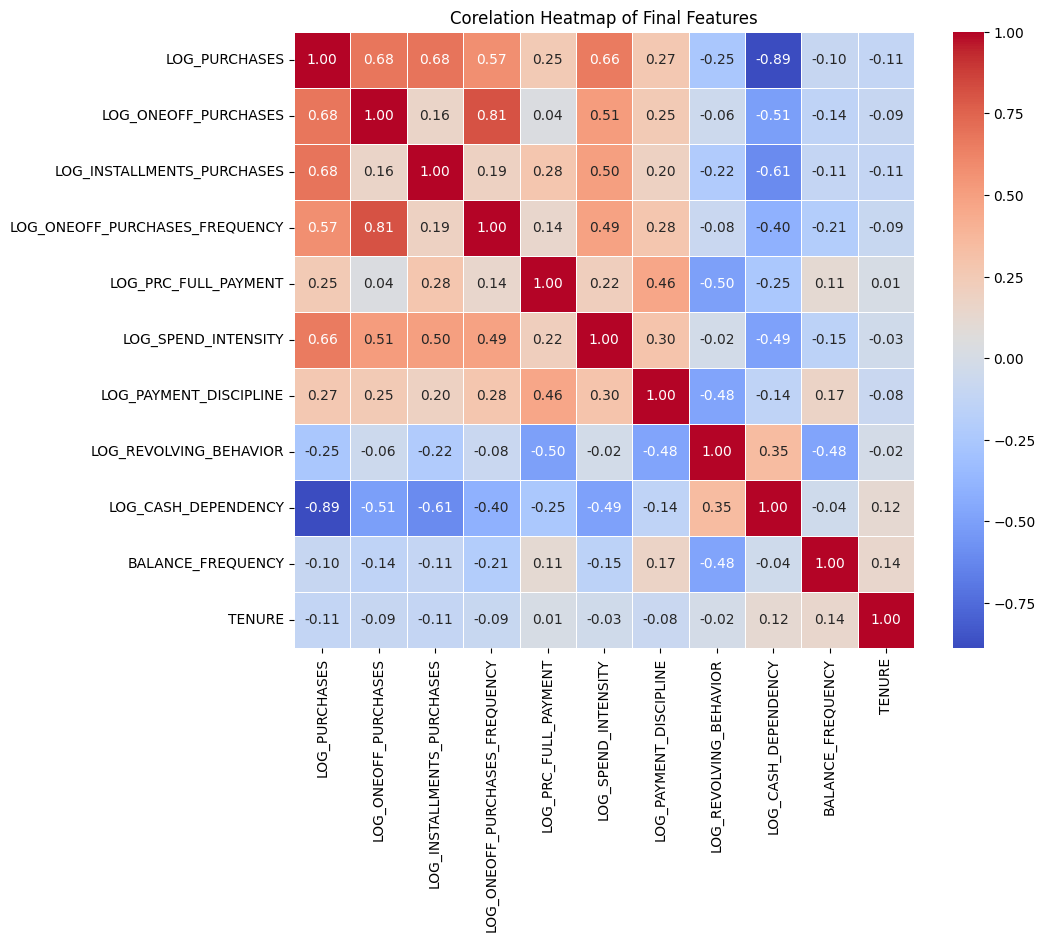

In [27]:
coor_matrix = df_clean[features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(coor_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Corelation Heatmap of Final Features")
plt.show() 

## Conclusion Correlation Heatmap — Final Engineered Features


> LOG_PURCHASES ↔ LOG_CASH_DEPENDENCY (-0.89)
The strongest signal in this entire heatmap. People who shop heavily almost never depend on cash advances. These are two completely opposite customer types — active shoppers vs cash-dependent borrowers. This single correlation confirms your segmentation is working.

> LOG_PURCHASES ↔ LOG_ONEOFF_PURCHASES (0.68) and LOG_INSTALLMENTS_PURCHASES (0.68)
Total spending is driven equally by both one-time and installment purchases. No single dominant spending style among shoppers — they do both.

> LOG_ONEOFF_PURCHASES ↔ LOG_ONEOFF_PURCHASES_FREQUENCY (0.81)
People who make big one-time purchases do it repeatedly. Luxury and impulse buying is a consistent habit, not a one-off event.

> LOG_PURCHASES ↔ LOG_SPEND_INTENSITY (0.66)
People who purchase more also utilize a higher proportion of their credit limit. High spenders are not just spending more in absolute terms — they're genuinely stretching their available credit.

> LOG_CASH_DEPENDENCY ↔ LOG_INSTALLMENTS_PURCHASES (-0.61)
Cash-dependent customers almost never use installment plans. They're not financing purchases — they're extracting cash. Completely different card usage pattern.

> LOG_REVOLVING_BEHAVIOR ↔ LOG_PRC_FULL_PAYMENT (-0.50)
The most behaviorally meaningful engineered signal. Customers who carry high revolving balance (close to their credit limit) never pay in full. These are your trapped revolvers — the balance keeps rolling because full payment is not in their habit.

> LOG_REVOLVING_BEHAVIOR ↔ LOG_PAYMENT_DISCIPLINE (-0.48)
Customers with high revolving behavior pay just enough to avoid penalties, not enough to reduce debt. High balance utilization and low payment discipline always go hand in hand — one causes the other.

> LOG_REVOLVING_BEHAVIOR ↔ BALANCE_FREQUENCY (-0.48)
Customers with high revolving behavior surprisingly have lower balance frequency scores. This means their balance isn't updated consistently — suggesting irregular usage patterns rather than chronic daily revolving.

> LOG_PRC_FULL_PAYMENT ↔ LOG_REVOLVING_BEHAVIOR (-0.50)
Full payers keep their revolving balance near zero. Disciplined customers treat the credit card as a convenience tool, not a borrowing instrument.

> LOG_CASH_DEPENDENCY ↔ LOG_SPEND_INTENSITY (-0.49)
Cash-dependent customers have low spend intensity — they aren't using their credit limit for purchases, they're draining it through cash withdrawals. Two completely different ways of exhausting a credit limit.

> LOG_PAYMENT_DISCIPLINE ↔ LOG_PRC_FULL_PAYMENT (0.46)
Expected and confirming. Customers who pay more than the minimum are the same people who frequently pay in full. Discipline is consistent — it shows up in both metrics simultaneously.

> TENURE ↔ everything (near 0)
TENURE is isolated from all behavioral features. How long someone has held the card tells you nothing about how they use it. It's a demographic fact, not a behavioral driver — useful as context but not a clustering signal.

> BALANCE_FREQUENCY ↔ everything (mostly near 0)
Similarly weak across the board. The frequency of balance updates doesn't strongly predict spending, repayment, or cash behavior. It's a passive metric — consider dropping it in the next iteration if silhouette score doesn't improve.

# Feature Scaling

In [28]:
X_raw = df_clean[features].copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f"✅ StandardScaler  applied")

✅ StandardScaler  applied


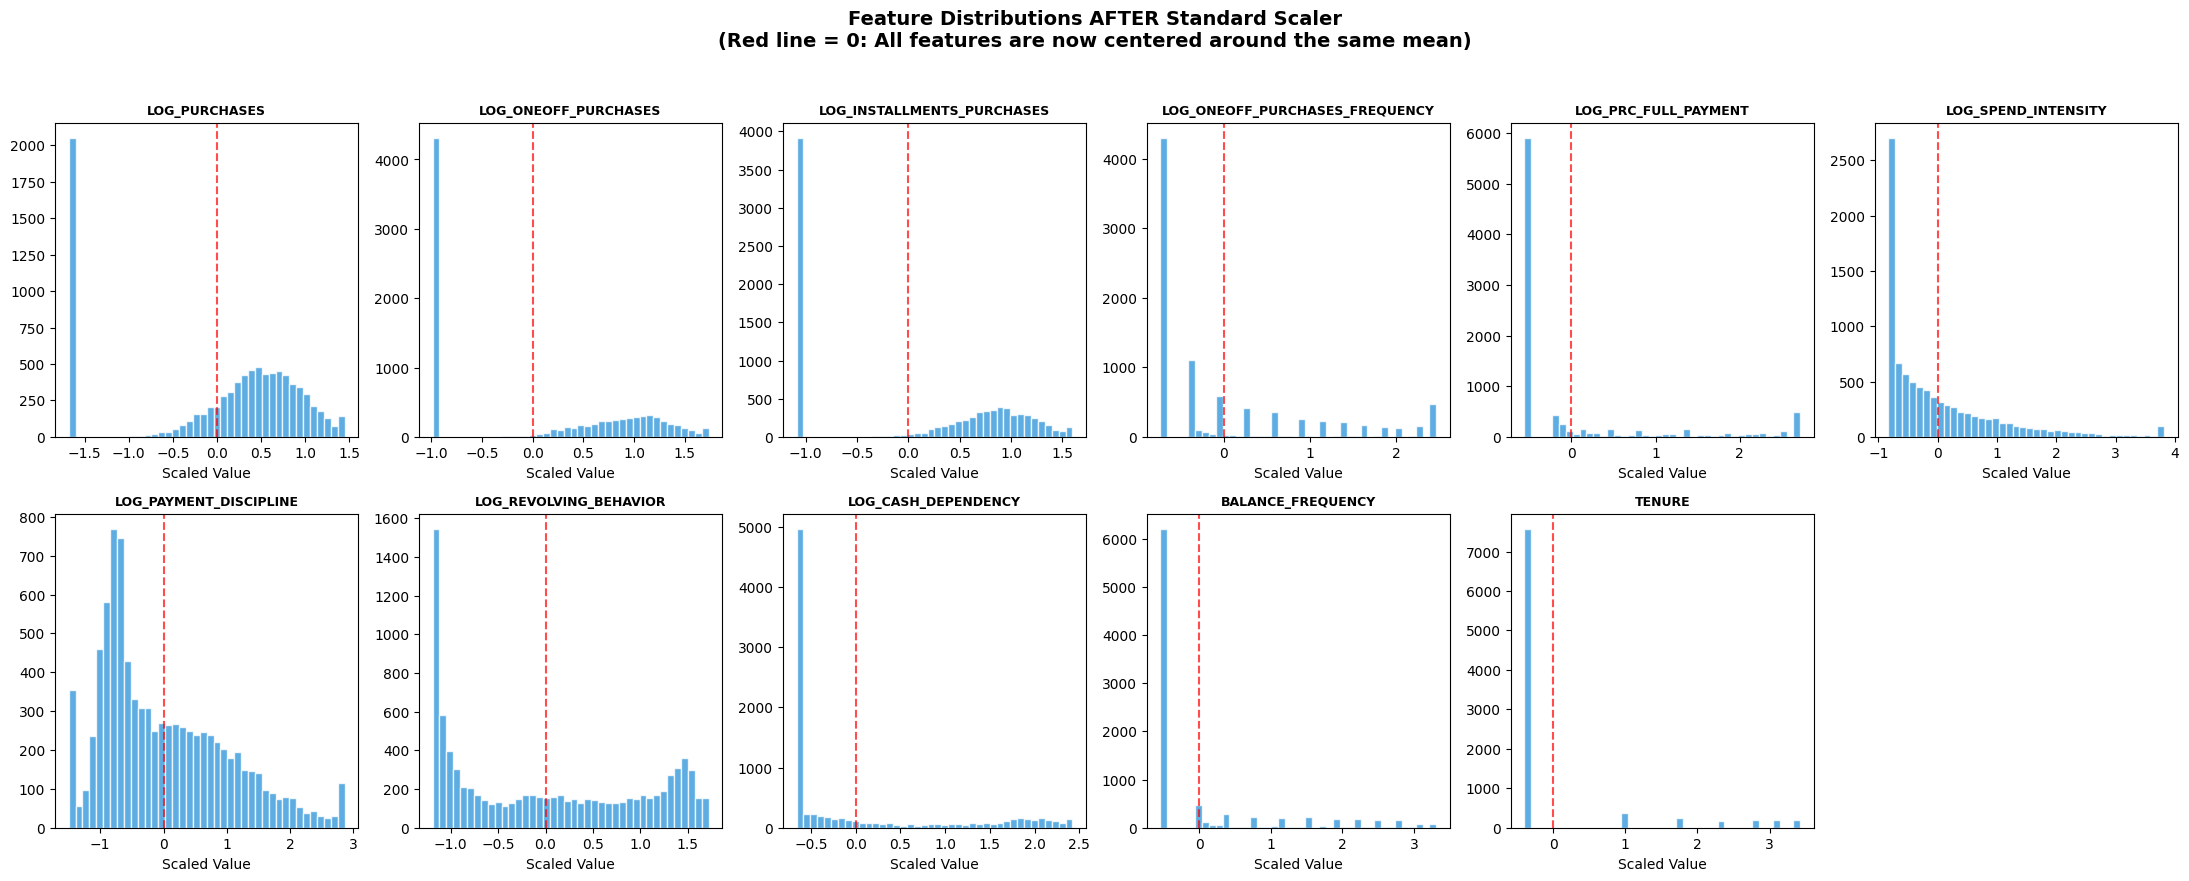

In [29]:
X_scaled_data = scaler.transform(X_raw) 
X_scaled_df = pd.DataFrame(X_scaled_data, columns=features)

# --- STEP 2: Visualise distributions AFTER scaling ---
fig, axes = plt.subplots(3, 6, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    # Flatten the values to ensure it's seen as ONE dataset
    data_to_plot = X_scaled_df[col].dropna().values.flatten()
    
    axes[i].hist(data_to_plot, bins=40, color='#3498db', alpha=0.8, edgecolor='white')
    
    axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    axes[i].set_xlabel('Scaled Value')


# Hide empty subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions AFTER Standard Scaler\n(Red line = 0: All features are now centered around the same mean)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

# PCA

In [30]:
pca = PCA()
pca.fit(X_scaled)



print("Variance per component:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var*100:5.1f}% ")

Variance per component:
  PC1:  37.6% 
  PC2:  18.2% 
  PC3:  10.7% 
  PC4:   9.4% 
  PC5:   8.3% 
  PC6:   5.3% 
  PC7:   3.9% 
  PC8:   2.6% 
  PC9:   2.4% 
  PC10:   1.3% 
  PC11:   0.4% 


In [31]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Captured variance per component:")
for i, var in enumerate(cumulative_variance, 1):
    print(f" {i} Component: {var*100:5.1f}% ")

Captured variance per component:
 1 Component:  37.6% 
 2 Component:  55.8% 
 3 Component:  66.4% 
 4 Component:  75.8% 
 5 Component:  84.1% 
 6 Component:  89.4% 
 7 Component:  93.3% 
 8 Component:  95.9% 
 9 Component:  98.3% 
 10 Component:  99.6% 
 11 Component: 100.0% 


### Using 8 PCA components, it captures abt 95.9% Variance.

In [32]:
pca_final = PCA(n_components=8, random_state=42)  
X_pca = pca_final.fit_transform(X_scaled)
print(f"✅ PCA applied | Shape: {X_pca.shape}")

✅ PCA applied | Shape: (8950, 8)


## 1. KMeans Clustring Model

In [33]:
inertia = []
silhouette_scores_km = []

k_values = range(2, 12)

for k in k_values:
    Kmeans = KMeans(
        n_clusters= k,
        random_state= 42,
        n_init= 20
    )

    labels = Kmeans.fit_predict(X_pca)
    inertia.append(Kmeans.inertia_)
    sil = silhouette_score(X_pca, labels, sample_size=5000, random_state=42)
    silhouette_scores_km.append(sil)
    print(f"  K={k:2d}  |  Inertia={Kmeans.inertia_:,.0f}  |  Silhouette={sil:.4f}")

print("\n✅ Done")

  K= 2  |  Inertia=68,285  |  Silhouette=0.2883
  K= 3  |  Inertia=56,489  |  Silhouette=0.2467
  K= 4  |  Inertia=47,751  |  Silhouette=0.2581
  K= 5  |  Inertia=43,206  |  Silhouette=0.2624
  K= 6  |  Inertia=39,434  |  Silhouette=0.2565
  K= 7  |  Inertia=35,945  |  Silhouette=0.2678
  K= 8  |  Inertia=32,967  |  Silhouette=0.2800
  K= 9  |  Inertia=30,705  |  Silhouette=0.2822
  K=10  |  Inertia=28,850  |  Silhouette=0.2881
  K=11  |  Inertia=27,436  |  Silhouette=0.2806

✅ Done


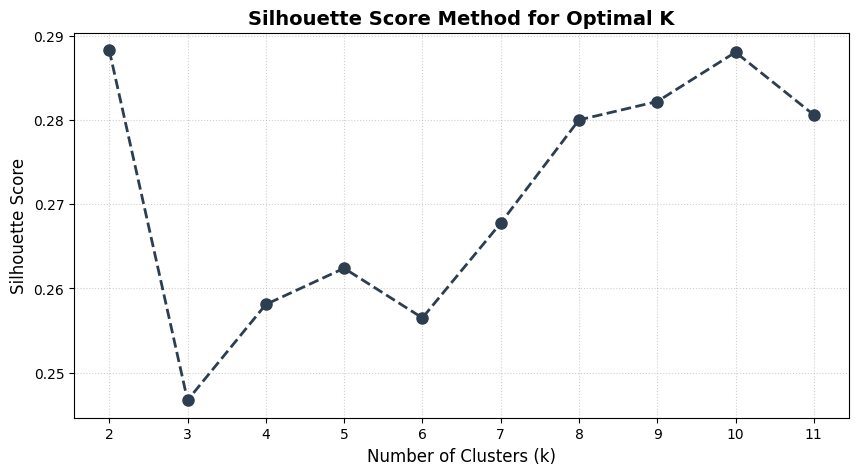

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plotting Silhouette Scores
plt.plot(k_values, silhouette_scores_km, marker='o', linestyle='--', color='#2c3e50', linewidth=2, markersize=8)

# Styling the graph
plt.title('Silhouette Score Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)

# Adding a vertical line at the peak (Optional)


plt.show()


## 2. GMM Clustring Model

In [35]:
# GMM with BIC to find optimal K


bic_scores = []
aic_scores = []
k_range    = range(2, 16)

print(f"{'K':<6} {'BIC':>12} {'AIC':>12}  {'ΔBIC':>10}")
print("-" * 46)

prev_bic = None
for k in k_range:
    gmm_test = GaussianMixture(n_components=k, random_state=42, covariance_type='diag', n_init=3)
    gmm_test.fit(X_pca)
    bic = gmm_test.bic(X_pca)
    aic = gmm_test.aic(X_pca)
    delta = bic - prev_bic if prev_bic is not None else 0
    bic_scores.append(bic)
    aic_scores.append(aic)
    print(f"  K={k:<3} | BIC={bic:>12.1f} | AIC={aic:>12.1f}  | ΔBIC={delta:>9.1f}")
    prev_bic = bic

optimal_k_gmm = list(k_range)[bic_scores.index(min(bic_scores))]
print(f"\n✅ Optimal K by BIC: {optimal_k_gmm}")

# Step 2 — Run final GMM with optimal K
gmm        = GaussianMixture(n_components=optimal_k_gmm, random_state=42, covariance_type='diag', n_init=3)
gmm_labels = gmm.fit_predict(X_pca)
gmm_sil    = silhouette_score(X_pca, gmm_labels, sample_size=5000, random_state=42)

print(f"GMM Silhouette Score (K={optimal_k_gmm}): {gmm_sil:.4f}")
print("\n✅ Done")


K               BIC          AIC        ΔBIC
----------------------------------------------
  K=2   | BIC=    184201.8 | AIC=    183967.6  | ΔBIC=      0.0
  K=3   | BIC=    173192.0 | AIC=    172837.0  | ΔBIC= -11009.8
  K=4   | BIC=    169826.1 | AIC=    169350.4  | ΔBIC=  -3365.9
  K=5   | BIC=    164748.1 | AIC=    164151.8  | ΔBIC=  -5078.0
  K=6   | BIC=    161215.2 | AIC=    160498.2  | ΔBIC=  -3532.9
  K=7   | BIC=    157537.1 | AIC=    156699.4  | ΔBIC=  -3678.1
  K=8   | BIC=    152912.3 | AIC=    151953.8  | ΔBIC=  -4624.9
  K=9   | BIC=    150898.5 | AIC=    149819.4  | ΔBIC=  -2013.7
  K=10  | BIC=    148813.3 | AIC=    147613.5  | ΔBIC=  -2085.2
  K=11  | BIC=    147238.7 | AIC=    145918.2  | ΔBIC=  -1574.7
  K=12  | BIC=    144607.6 | AIC=    143166.4  | ΔBIC=  -2631.1
  K=13  | BIC=    142931.0 | AIC=    141369.1  | ΔBIC=  -1676.6
  K=14  | BIC=    141145.1 | AIC=    139462.5  | ΔBIC=  -1785.9
  K=15  | BIC=    139349.0 | AIC=    137545.8  | ΔBIC=  -1796.1

✅ Optimal K

## 3. Agglomerative Clustring Model

In [36]:
silhouette_scores_agg = []
k_values = range(2, 12)

print("--- Running Agglomerative Clustering ---")

for k in k_values:

    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_pca)
    
    sil = silhouette_score(X_pca, labels, sample_size=5000, random_state=42)
    silhouette_scores_agg.append(sil)
    
    print(f"  K={k:2d}  |  Silhouette={sil:.4f}")

print("\n✅ Done")


--- Running Agglomerative Clustering ---
  K= 2  |  Silhouette=0.2955
  K= 3  |  Silhouette=0.2192
  K= 4  |  Silhouette=0.2303
  K= 5  |  Silhouette=0.2429
  K= 6  |  Silhouette=0.2407
  K= 7  |  Silhouette=0.2407
  K= 8  |  Silhouette=0.2467
  K= 9  |  Silhouette=0.2450
  K=10  |  Silhouette=0.2401
  K=11  |  Silhouette=0.2166

✅ Done


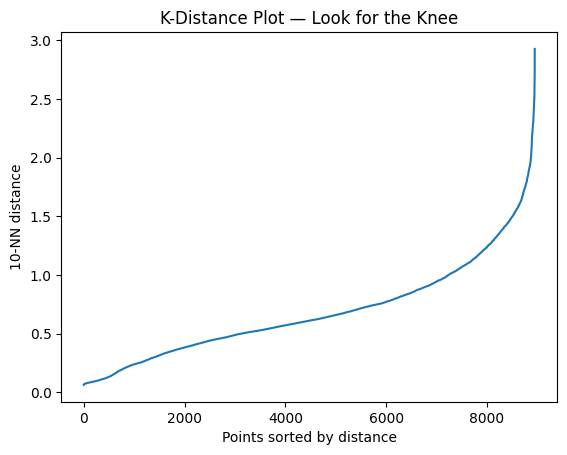

In [37]:
from sklearn.neighbors import NearestNeighbors
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
distances = np.sort(distances[:, k-1])
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN distance")
plt.title("K-Distance Plot — Look for the Knee")
plt.show()

assigning esp=2 since the elbow is forming at 2

# 4. DBScan Clustering Model 

In [38]:
dbscan = DBSCAN(eps=1.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)
print(f"Estimated number of clusters: {n_clusters_dbscan}")
print(f"Estimated number of noise points: {n_noise_dbscan}")
dbscan_sil = silhouette_score(X_pca, dbscan_labels)
print(f"Silhouette Score DBScan: {dbscan_sil:.4f}")

Estimated number of clusters: 1
Estimated number of noise points: 42
Silhouette Score DBScan: 0.2601


## Using KMeans as the Final Model

In [39]:
best_k = 4
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_clean['cluster'] = kmeans_final.fit_predict(X_pca)

print(f"✅ Final KMeans with K={best_k} applied")
print()
print("Cluster sizes:")
print(df_clean['cluster'].value_counts().sort_index())

✅ Final KMeans with K=4 applied

Cluster sizes:
cluster
0    2936
1    2071
2    1777
3    2166
Name: count, dtype: int64


## 3D Plot

In [40]:
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans

# 1. Define optimal K based on your silhouette scores (replace with your best K)
OPTIMAL_K = 4 

# 2. Refit KMeans with the chosen K (since the loop overwrote the 'labels' variable)
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
labels_final = kmeans_final.fit_predict(X_pca)

# 3. Extract the first 3 PCs for spatial plotting
df_plot = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])

# 4. Cast labels to strings for discrete categorical colors
df_plot['Cluster'] = labels_final.astype(str) 

# 5. Generate the interactive 3D scatter plot
fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title=f'K-Means Clustering (K={OPTIMAL_K}) on First 3 Principal Components',
    color_discrete_sequence=px.colors.qualitative.Bold
)


fig.show()

In [41]:
# 1. Use px.scatter for 2D instead of scatter_3d
fig_2d = px.scatter(
    df_plot,
    x='PC1',
    y='PC2',
    color='Cluster',
    title=f'2D K-Means Clustering (K={OPTIMAL_K})',
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_white' # Optional: cleaner look for 2D
)

# 2. Update layout to keep the plot square (optional, helps visualize distance)
fig_2d.update_layout(width=800, height=600)

fig_2d.show()


# Cluster Profiling

In [42]:
profile_cols = ['BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY',
       'PRC_FULL_PAYMENT', 'TENURE', 'SPEND_INTENSITY', 'PAYMENT_DISCIPLINE',
       'REVOLVING_BEHAVIOR', 'CASH_DEPENDENCY']

cluster_profile = df_clean.groupby('cluster')[profile_cols].mean().round(2)
print("---------- CLUSTER PROFILES (mean values per cluster) -----------")
print(cluster_profile.to_string())

---------- CLUSTER PROFILES (mean values per cluster) -----------
         BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  ONEOFF_PURCHASES_FREQUENCY  PRC_FULL_PAYMENT  TENURE  SPEND_INTENSITY  PAYMENT_DISCIPLINE  REVOLVING_BEHAVIOR  CASH_DEPENDENCY
cluster                                                                                                                                                                                                        
0                     0.01     712.50            367.91                  334.29                        0.18              0.01    0.18             0.24                1.67                0.59             3.35
1                     0.09       1.08              0.67                    0.45                        0.00              0.03    0.28             0.00                3.70                0.58          1818.11
2                     0.03    2930.52           1959.16                  918.96                       

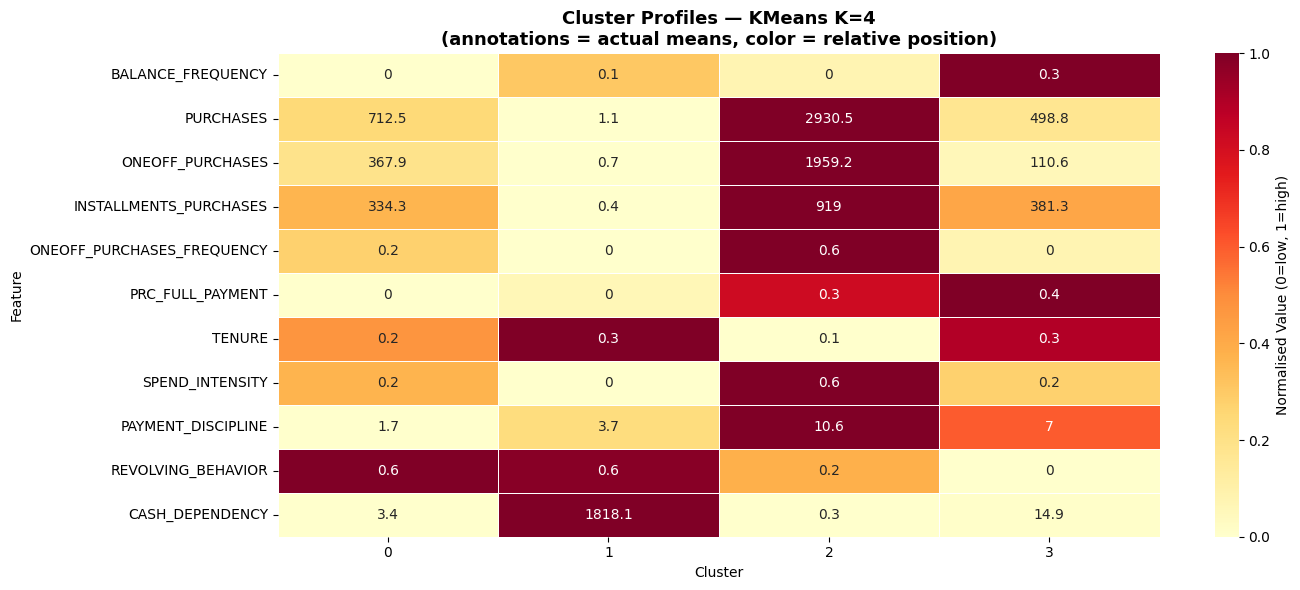

In [43]:

profile_norm = cluster_profile.copy()
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

plt.figure(figsize=(14, 6))
sns.heatmap(profile_norm.T, annot=cluster_profile.T.round(1),
            fmt='g', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Normalised Value (0=low, 1=high)'})
plt.title(f'Cluster Profiles — KMeans K={best_k}\n(annotations = actual means, color = relative position)',
          fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Cluster 0 — "The Silent Revolver" 🟡

The Comfortable Drifter
Who they are: Moderate spender — ₹712 in purchases, ₹367 one-time, ₹334 installments. Looks normal on the surface. But revolving behavior is 0.6 and they have never paid in full (PRC_FULL_PAYMENT = 0). Payment discipline is only 1.7 — barely above minimum. They shop, but never clear the balance.

Psychology: Not in panic, not financially stressed — just perpetually behind. Every month they intend to clear it, every month they don't. The debt rolls silently. They don't feel like they have a problem because they're not pulling cash from ATMs — but compounding interest is quietly eroding them.

In one line: "I'll pay it off next month" — said every month for years.

Business: Steady interest income, medium risk. Offer structured payoff plans before the debt spiral deepens.

Cluster 1 — "The Cash Dependent" 🔴
The Firefighter

Who they are: This person doesn't use their credit card to shop. They use it as an ATM. Their CASH_DEPENDENCY ratio is 1818 — meaning for every ₹1 spent on purchases, they withdraw ₹1818 in cash. Purchases are near zero. Balance is 60% of their credit limit and it never gets cleared.

Psychology: Financially stressed. Living month to month. The card is a survival tool, not a lifestyle one. They pay the minimum because that's genuinely all they can afford.In 

one line: "I don't buy things with my card — I use it to survive.

"Business: Highest short-term revenue (cash advance fees + interest). Highest default risk. Don't raise their limit. Offer EMI restructuring.

Cluster 2 — "The Power Spender" 🟢
The Lifestyle Transactor
Who they are: The bank's dream customer. Highest purchases at ₹2930, highest one-time buys at ₹1959, highest installments at ₹919. They spend across every category. Yet their revolving balance is only 0.2 and payment discipline is 10.6x the minimum — they spend big and pay big.

Psychology: High earner who treats the credit card as a financial tool, not borrowed money. Swipes for rewards, cashback, and convenience. The bill is just a monthly formality they clear comfortably.

In one line: "My card is my wallet — I spend freely and settle in full."

Business: Maximum interchange fee revenue, near-zero default risk. Highest priority for premium card upgrades, travel perks, and retention offers.

Cluster 3 — "The Disciplined Payer" 🔵

The Responsible Professional
Who they are: Highest full payment rate at 0.4 and payment discipline at 7x the minimum. Revolving balance is essentially zero. Moderate purchases at ₹499. They use the card consistently but never let debt accumulate. Even their occasional cash advances (CASH_DEPENDENCY 14.9) get cleared — their revolving balance stays at zero regardless.

Psychology: Treats credit as a 30-day interest-free convenience, not a borrowing facility. Pays on salary day, every month, without fail. Financially aware and in control.

In one line: "I use credit for the benefits, not because I need it."

Business: Lowest risk, lowest interest revenue. Most loyal segment. Increase their credit limit and offer rewards — they'll route more spending through the card without any default risk.

## One-Page Summary

| Attribute | Cluster 1 | Cluster 2 | Cluster 0 | Cluster 3 |
|---|---|---|---|---|
| **Label** | Cash Dependent | Power Spender | Silent Revolver | Disciplined Payer |
| **Spending** | Near Zero | Very High | Moderate | Moderate |
| **Cash Advance** | Extreme | Never | Occasionally | Rarely |
| **Pays in Full** | Never | Often | Never | Frequently |
| **Debt Level** | High | Low | High | Zero |
| **Psychology** | Survival mode | Wealth routing | Comfortable denial | Financial control |
| **Risk** | 🔴 Very High | 🟢 Low | 🟡 Medium | 🔵 Very Low |
| **Bank Strategy** | Restructure debt | Retain & upsell | Payoff incentives | Limit increase |

## Radar / Spider Charts — Executive Presentation

Each chart shows the **normalised behavioural fingerprint** of one customer segment across six key dimensions.  
Values are scaled 0 → 1 (low → high) so segments can be compared visually at a glance.

C:\Users\david\AppData\Local\Temp\ipykernel_23876\939255259.py:99: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\939255259.py:99: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\939255259.py:99: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\939255259.py:99: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\939255259.py:100: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_radar_charts.png', dpi=150, bbox_inches='tight',
C:\Users\david\AppData\Local\Temp\ipykernel_23876\939255259.py:100: UserWarning: Gly

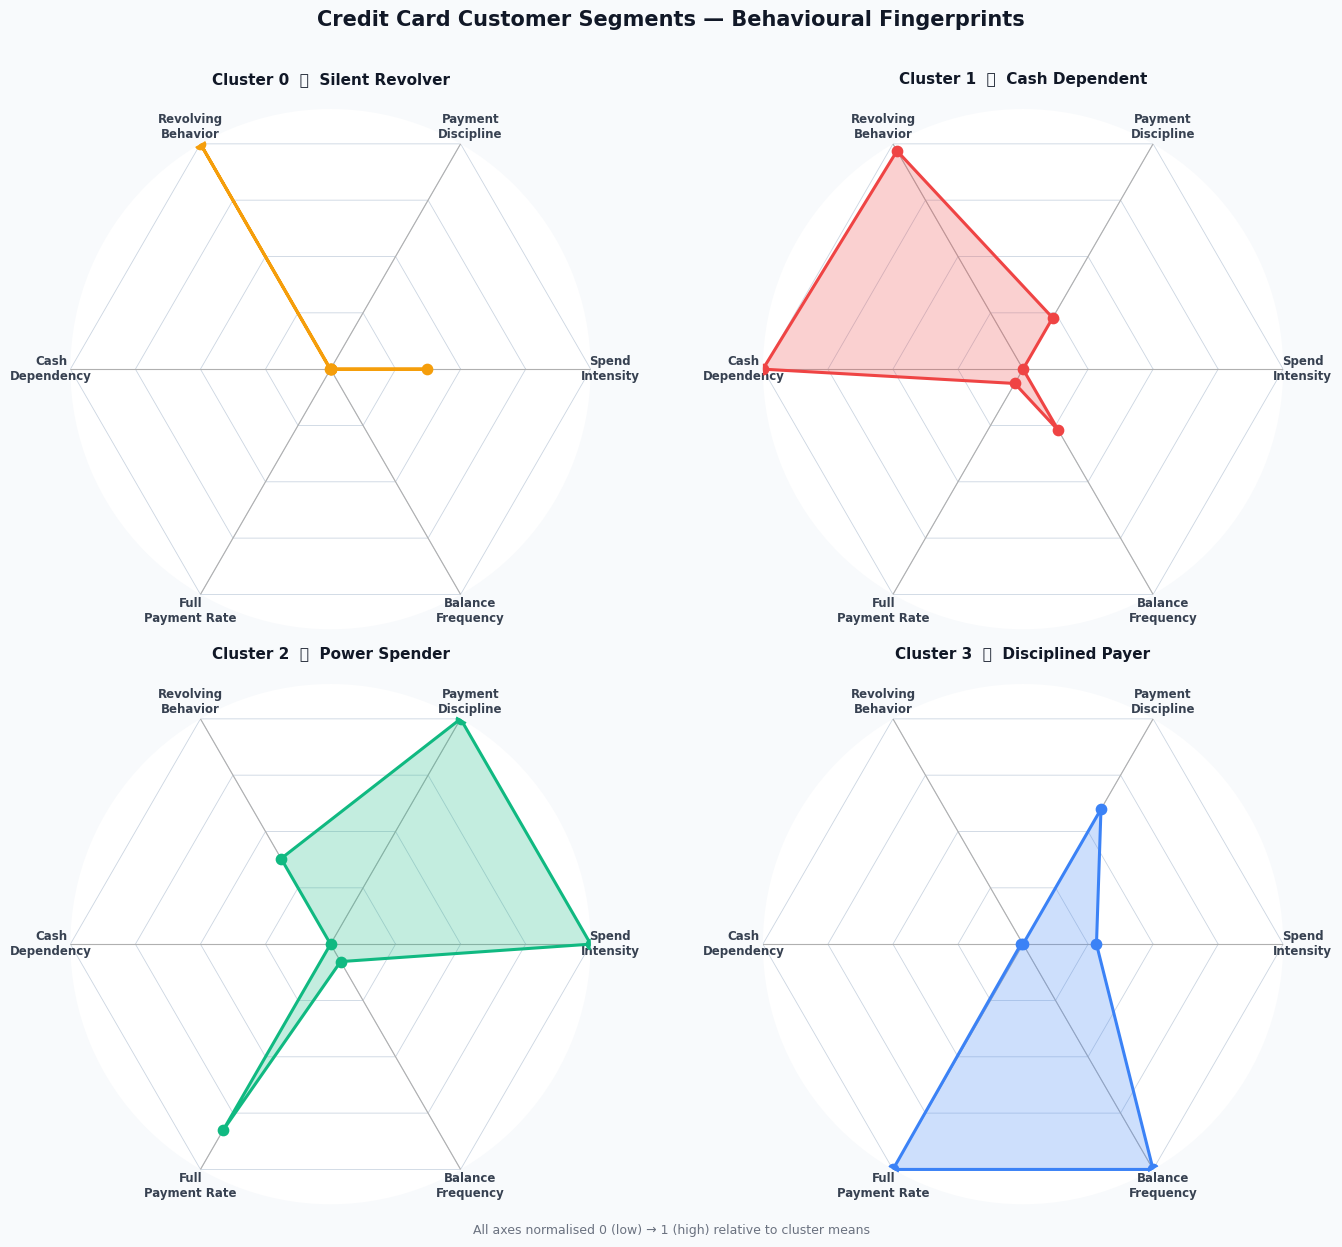

Radar charts saved to cluster_radar_charts.png


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1.  Build the radar data ────────────────────────────────────────────────
# Six interpretable dimensions chosen for an executive audience
radar_cols = [
    'SPEND_INTENSITY',
    'PAYMENT_DISCIPLINE',
    'REVOLVING_BEHAVIOR',
    'CASH_DEPENDENCY',
    'PRC_FULL_PAYMENT',
    'BALANCE_FREQUENCY',
]

radar_labels = [
    'Spend\nIntensity',
    'Payment\nDiscipline',
    'Revolving\nBehavior',
    'Cash\nDependency',
    'Full\nPayment Rate',
    'Balance\nFrequency',
]

# Pull mean values per cluster
radar_profile = df_clean.groupby('cluster')[radar_cols].mean()

# Normalise each feature to [0, 1] across cluster means so shape is comparable
radar_norm = (radar_profile - radar_profile.min()) / (radar_profile.max() - radar_profile.min())
radar_norm = radar_norm.fillna(0)          # guard against zero-range features

# Cluster metadata — order matches cluster IDs 0-3
cluster_meta = {
    0: {'label': 'Silent Revolver',   'emoji': '🟡', 'color': '#F59E0B'},
    1: {'label': 'Cash Dependent',    'emoji': '🔴', 'color': '#EF4444'},
    2: {'label': 'Power Spender',     'emoji': '🟢', 'color': '#10B981'},
    3: {'label': 'Disciplined Payer', 'emoji': '🔵', 'color': '#3B82F6'},
}

# ── 2.  Helper: draw one radar ──────────────────────────────────────────────
def draw_radar(ax, values, color, title, alpha_fill=0.25):
    N = len(values)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    # close the polygon
    values_c  = values  + [values[0]]
    angles_c  = angles  + [angles[0]]

    # circular grid
    for r in [0.25, 0.50, 0.75, 1.0]:
        ax.plot(angles_c, [r] * (N + 1), color='#CBD5E1', linewidth=0.6, zorder=1)

    # spokes
    for a in angles:
        ax.plot([a, a], [0, 1], color='#CBD5E1', linewidth=0.6, zorder=1)

    # filled area
    ax.fill(angles_c, values_c, alpha=alpha_fill, color=color, zorder=2)
    # border line
    ax.plot(angles_c, values_c, color=color, linewidth=2.2, zorder=3)
    # dots at vertices
    ax.scatter(angles, values, color=color, s=55, zorder=4)

    # axis labels
    ax.set_xticks(angles)
    ax.set_xticklabels(radar_labels, fontsize=8.5, fontweight='bold', color='#374151')
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=18, color='#111827')
    ax.spines['polar'].set_visible(False)

# ── 3.  Plot 2 × 2 grid ─────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 12),
    subplot_kw=dict(polar=True),
)
fig.patch.set_facecolor('#F8FAFC')

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for cluster_id, (r, c) in zip(range(4), positions):
    meta   = cluster_meta[cluster_id]
    values = radar_norm.loc[cluster_id, radar_cols].tolist()
    title  = f"Cluster {cluster_id}  {meta['emoji']}  {meta['label']}"
    ax     = axes[r][c]
    ax.set_facecolor('white')
    draw_radar(ax, values, meta['color'], title)

fig.suptitle(
    'Credit Card Customer Segments — Behavioural Fingerprints',
    fontsize=15, fontweight='bold', y=1.01, color='#111827',
)

fig.text(
    0.5, -0.01,
    'All axes normalised 0 (low) → 1 (high) relative to cluster means',
    ha='center', fontsize=9, color='#6B7280',
)

plt.tight_layout()
plt.savefig('cluster_radar_charts.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Radar charts saved to cluster_radar_charts.png')


### All-Cluster Overlay (single chart for quick comparison)

C:\Users\david\AppData\Local\Temp\ipykernel_23876\2926032661.py:44: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\2926032661.py:44: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\2926032661.py:44: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\2926032661.py:44: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\david\AppData\Local\Temp\ipykernel_23876\2926032661.py:45: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_radar_overlay.png', dpi=150, bbox_inches='tight',
C:\Users\david\AppData\Local\Temp\ipykernel_23876\2926032661.py:45: UserWarning

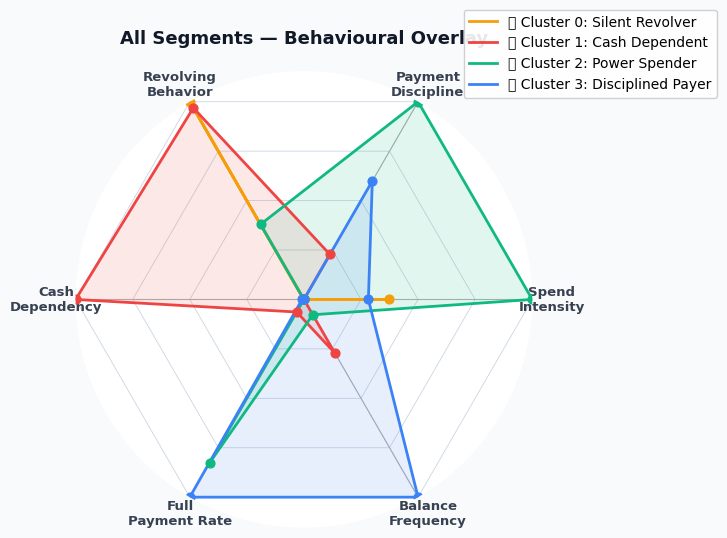

Overlay chart saved to cluster_radar_overlay.png


In [45]:
fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig2.patch.set_facecolor('#F8FAFC')
ax2.set_facecolor('white')

N = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# grid rings
for r in [0.25, 0.50, 0.75, 1.0]:
    ax2.plot(angles + [angles[0]], [r] * (N + 1),
             color='#CBD5E1', linewidth=0.6, zorder=1)
for a in angles:
    ax2.plot([a, a], [0, 1], color='#CBD5E1', linewidth=0.6, zorder=1)

for cluster_id in range(4):
    meta   = cluster_meta[cluster_id]
    values = radar_norm.loc[cluster_id, radar_cols].tolist()
    values_c = values + [values[0]]
    angles_c = angles + [angles[0]]

    ax2.fill(angles_c, values_c, alpha=0.12, color=meta['color'], zorder=2)
    ax2.plot(angles_c, values_c, color=meta['color'],
             linewidth=2, label=f"{meta['emoji']} Cluster {cluster_id}: {meta['label']}",
             zorder=3)
    ax2.scatter(angles, values, color=meta['color'], s=40, zorder=4)

ax2.set_xticks(angles)
ax2.set_xticklabels(radar_labels, fontsize=9.5, fontweight='bold', color='#374151')
ax2.set_yticks([])
ax2.set_ylim(0, 1)
ax2.spines['polar'].set_visible(False)
ax2.set_title(
    'All Segments — Behavioural Overlay',
    fontsize=13, fontweight='bold', pad=20, color='#111827',
)

ax2.legend(
    loc='upper right',
    bbox_to_anchor=(1.42, 1.15),
    fontsize=10,
    framealpha=0.9,
)

plt.tight_layout()
plt.savefig('cluster_radar_overlay.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print('Overlay chart saved to cluster_radar_overlay.png')
